# Trading Order Book Analysis with ROOT

This notebook demonstrates how to use CERN ROOT framework for analyzing trading order book data. It performs:

- **Data conversion**: Converting pandas DataFrames to ROOT TTree format
- **Trader analysis**: Group-by aggregations per trader using ROOT histograms
- **Statistical analysis**: Computing z-scores to identify abnormal trading patterns
- **Time-series analysis**: Analyzing trading activity over time

The analysis focuses on detecting suspicious trading behaviors such as quote stuffing (high cancel rates) and unusual trading patterns.

In [1]:
#!rm -rf /content/root /content/root_v*.tar.gz

In [2]:
import os, sys

# Remove any sys.path entries pointing to /content/root
sys.path = [p for p in sys.path if "/content/root" not in p]

# Remove env vars that can force Python to load the old ROOT
for k in ["ROOTSYS", "PYTHONPATH", "LD_LIBRARY_PATH"]:
    if k in os.environ and "/content/root" in os.environ[k]:
        del os.environ[k]

print("Cleaned. Now restart the runtime.")


Cleaned. Now restart the runtime.


In [3]:
#import os, signal
#os.kill(os.getpid(), signal.SIGKILL)


In [4]:
!pip -q install -U pip
!pip -q install -i https://root-experimental-python-wheels.web.cern.ch ROOT


In [5]:
import ROOT
print("ROOT version:", ROOT.gROOT.GetVersion())


/usr/local/lib/python3.12/dist-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.12); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


ROOT version: 6.38.00


In [6]:
pip install uproot

In [7]:
import uproot

In [8]:
import pandas as pd
import numpy as np

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ROOT Analysis

ROOT's RDataFrame provides a modern, efficient interface for data analysis with automatic parallelization. The following sections demonstrate various analyses of the trading data.

In [10]:
import pandas as pd

# Please update this path with the correct location of your parquet file in Google Drive.
df = pd.read_parquet("/content/drive/MyDrive/Colab Notebooks/CERN/order_data_combined.parquet")
display(df.head())

,order_id,trader_id,side,price,quantity,remaining,event_type,order_type,timestamp,status
0,1,TRADER_001,Sell,101.63,150,99,TRADE,Limit,2026-01-19 01:06:57.804,Partially filled
1,2,TRADER_002,Buy,101.14,300,0,TRADE,Limit,2026-01-19 00:21:47.758,Filled
2,3,TRADER_003,Buy,101.16,300,0,TRADE,Limit,2026-01-18 20:12:07.899,Filled
3,4,TRADER_004,Sell,101.38,300,108,TRADE,Limit,2026-01-18 17:27:21.554,Partially filled
4,5,TRADER_005,Buy,101.38,200,115,TRADE,Limit,2026-01-18 14:11:56.834,Partially filled


In [11]:
import numpy as np
import uproot

# Convert timestamp to nanoseconds (ts_ns) for ROOT processing
if "timestamp" in df.columns:
    if df["timestamp"].dtype == "object" or "datetime" in str(df["timestamp"].dtype):
        # Convert datetime to nanoseconds since epoch
        df["ts_ns"] = (pd.to_datetime(df["timestamp"]).astype("int64")).astype(np.int64)
    else:
        # If already numeric, assume it's in nanoseconds or convert appropriately
        df["ts_ns"] = df["timestamp"].astype(np.int64)
    print("Converted timestamp to ts_ns (nanoseconds)")

# Start with all columns except timestamp (we use ts_ns instead)
write_cols = [c for c in df.columns if c != "timestamp"]

# Convert event_type to numeric codes before writing (ROOT can't handle strings in C++ expressions)
# 0 = NEW, 1 = CANCEL, 2 = TRADE
if "event_type" in df.columns and df["event_type"].dtype == "object":
    event_type_map = {"NEW": 0, "CANCEL": 1, "TRADE": 2}
    df["event_type_code"] = df["event_type"].map(event_type_map).astype(np.int32)
    if "event_type" in write_cols:
        write_cols.remove("event_type")
    write_cols.append("event_type_code")
    print("Converted event_type to numeric codes: NEW=0, CANCEL=1, TRADE=2")

# Convert trader_id to numeric if it's a string (using factorize to create numeric IDs)
if "trader_id" in df.columns and df["trader_id"].dtype == "object":
    trader_ids, unique_traders = pd.factorize(df["trader_id"])
    df["trader_id_code"] = trader_ids.astype(np.int32)
    if "trader_id" in write_cols:
        write_cols.remove("trader_id")
    write_cols.append("trader_id_code")
    print(f"Converted trader_id to numeric codes ({len(unique_traders)} unique traders)")

# (Optional) also drop any remaining object/string columns that sneak in
bad = []
for c in write_cols:
    if df[c].dtype == "object":
        bad.append(c)
if bad:
    print("Dropping remaining object columns:", bad)
    write_cols = [c for c in write_cols if c not in bad]

data = {c: df[c].to_numpy() for c in write_cols}

with uproot.recreate("lob.root") as f:
    f.mktree("events", data)   # explicitly creates a TTree
    f["events"].extend(data)   # write the arrays

print(f"\nWritten {len(data)} columns to lob.root")
print(f"Columns: {list(data.keys())}")


Converted timestamp to ts_ns (nanoseconds)
Converted event_type to numeric codes: NEW=0, CANCEL=1, TRADE=2
Converted trader_id to numeric codes (1008 unique traders)
Dropping remaining object columns: ['side', 'order_type', 'status']

Written 7 columns to lob.root
Columns: ['order_id', 'price', 'quantity', 'remaining', 'ts_ns', 'event_type_code', 'trader_id_code']


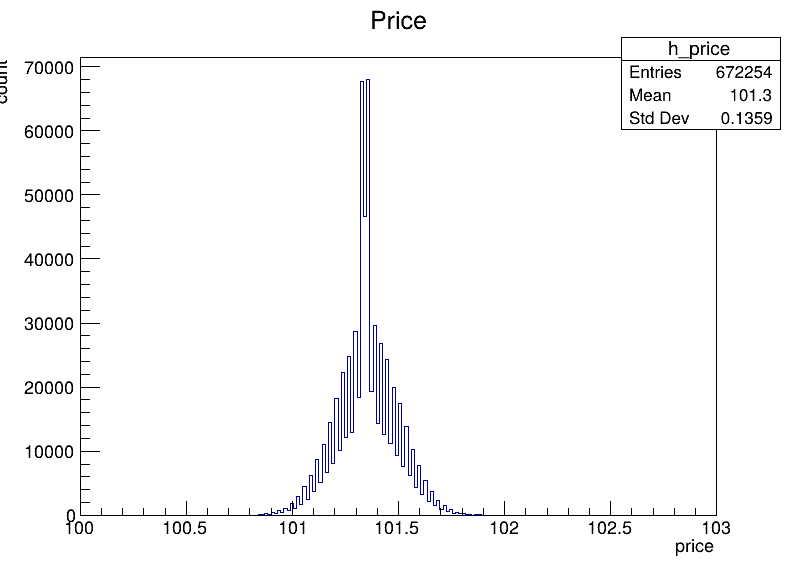

In [12]:
ROOT.EnableImplicitMT()

df = ROOT.RDataFrame("events", "lob.root")

# Example histogram: price distribution
h_price = df.Histo1D(("h_price", "Price;price;count", 200, 100, 103), "price")

c1 = ROOT.TCanvas("c1", "c1", 800, 600)
h_price.Draw()
c1.Draw()   # <- this makes it appear inline in Colab


In [13]:

ROOT.EnableImplicitMT()

rdf = ROOT.RDataFrame("events", "lob.root")
print(rdf.GetColumnNames())


{ "event_type_code", "order_id", "price", "quantity", "remaining", "trader_id_code", "ts_ns" }


In [14]:
import ROOT
ROOT.EnableImplicitMT()

rdf = ROOT.RDataFrame("events", "lob.root")

# First, let's check what columns are available
print("Available columns in ROOT file:")
for col in rdf.GetColumnNames():
    print(f"  - {col}")

# Define boolean flags for event types (event_type_code: 0=NEW, 1=CANCEL, 2=TRADE)
rdf2 = (rdf
    .Define("is_new",    "event_type_code == 0")  # NEW = 0
    .Define("is_cancel", "event_type_code == 1")  # CANCEL = 1
    .Define("is_trade",  "event_type_code == 2")  # TRADE = 2
    .Define("sec",       "ts_ns / 1000000000.0")  # Convert nanoseconds to seconds
)




Available columns in ROOT file:
  - event_type_code
  - order_id
  - price
  - quantity
  - remaining
  - trader_id_code
  - ts_ns


Group by

In [15]:
import ROOT
import numpy as np
ROOT.EnableImplicitMT()

rdf = ROOT.RDataFrame("events", "lob.root")

# Define flags (make sure these column names exist in your ROOT file)
rdf2 = (rdf
    .Define("is_new",    "event_type_code == 0")
    .Define("is_cancel", "event_type_code == 1")
    .Define("is_trade",  "event_type_code == 2")
    .Define("w_new",     "double(is_new)")
    .Define("w_cancel",  "double(is_cancel)")
    .Define("w_trade",   "double(is_trade)")
)

# Assume trader_id_code are contiguous ints 0..N-1 (as from pandas category codes)
max_id = int(rdf2.Max("trader_id_code").GetValue())
nbins = max_id + 1

# Histograms = group-by aggregations
h_msgs   = rdf2.Histo1D(("h_msgs",   "", nbins, -0.5, nbins - 0.5), "trader_id_code")
h_new    = rdf2.Histo1D(("h_new",    "", nbins, -0.5, nbins - 0.5), "trader_id_code", "w_new")
h_cancel = rdf2.Histo1D(("h_cancel", "", nbins, -0.5, nbins - 0.5), "trader_id_code", "w_cancel")
h_trade  = rdf2.Histo1D(("h_trade",  "", nbins, -0.5, nbins - 0.5), "trader_id_code", "w_trade")

# Bring results back to Python (like AsNumpy on a grouped table)
trader_ids = np.arange(nbins, dtype=np.int32)
res = {
    "trader_id_code": trader_ids,
    "n_msgs":   np.array([h_msgs.GetBinContent(i+1)   for i in range(nbins)], dtype=np.int64),
    "n_new":    np.array([h_new.GetBinContent(i+1)    for i in range(nbins)], dtype=np.int64),
    "n_cancel": np.array([h_cancel.GetBinContent(i+1) for i in range(nbins)], dtype=np.int64),
    "n_trade":  np.array([h_trade.GetBinContent(i+1)  for i in range(nbins)], dtype=np.int64),
}
res


{'trader_id_code': array([   0,    1,    2, ..., 1005, 1006, 1007], dtype=int32),
 'n_msgs': array([572, 674, 496, ..., 480, 518, 488]),
 'n_new': array([212, 244, 180, ..., 174, 192, 180]),
 'n_cancel': array([108, 114,  88, ...,  94, 118,  88]),
 'n_trade': array([252, 316, 228, ..., 212, 208, 220])}

# NEW

In [16]:
%jsroot on
import ROOT
ROOT.EnableImplicitMT()


**Plot Descriptions:**

1. **Message Counts per Trader**: This histogram displays the total number of messages (all event types) sent by each trader. The x-axis shows trader ID codes, and the y-axis shows the message count. Traders with unusually high message counts may be engaging in high-frequency trading or quote stuffing.

2. **Message Count Z-Scores**: This histogram shows the z-scores for message counts per trader. Z-scores indicate how many standard deviations away from the mean each trader's message count is. Values with |z| > 2 or 3 are considered outliers and may indicate suspicious trading behavior (e.g., excessive messaging compared to the average trader).

In [17]:
rdf = ROOT.RDataFrame("events", "lob.root")

# sanity: check columns exist
# print(list(rdf.GetColumnNames()))

# Flags (adjust codes if yours differ)
rdf2 = (rdf
    .Define("is_new",    "event_type_code == 0")
    .Define("is_cancel", "event_type_code == 1")
    .Define("is_trade",  "event_type_code == 2")
    .Define("w_new",     "double(is_new)")
    .Define("w_cancel",  "double(is_cancel)")
    .Define("w_trade",   "double(is_trade)")
)

# trader_id_code assumed 0..max (category codes)
max_id = int(rdf2.Max("trader_id_code").GetValue())
nbins = max_id + 1

# "Group-by" via histograms
h_msgs = rdf2.Histo1D(
    ("h_msgs", "Messages per trader;trader_id_code;count", nbins, -0.5, nbins-0.5),
    "trader_id_code"
).GetValue()

# Make z-score histogram (same binning)
h_z = ROOT.TH1D("h_z", "Message-count z-score;trader_id_code;z", nbins, -0.5, nbins-0.5)

mean = h_msgs.GetMean()
rms  = h_msgs.GetRMS()
if rms == 0:
    rms = 1.0

for b in range(1, nbins+1):
    x = h_msgs.GetBinContent(b)
    z = (x - mean) / rms
    h_z.SetBinContent(b, z)

# Plot
c = ROOT.TCanvas("c_msgs", "c_msgs", 1000, 400)
h_msgs.Draw("HIST")
c.Draw()

c2 = ROOT.TCanvas("c_z", "c_z", 1000, 400)
h_z.Draw("HIST")
c2.Draw()


**Plot Descriptions:**

1. **Cancel Rate per Trader**: This histogram shows the cancel-to-new order ratio for each trader (cancels divided by new orders). A ratio close to 1.0 indicates a trader cancels almost as many orders as they create, which is a red flag for quote stuffing behavior. Normal traders typically have lower cancel rates.

2. **Cancel Rate Z-Scores**: This histogram displays z-scores for cancel rates, highlighting traders whose cancel rates deviate significantly from the mean. High positive z-scores indicate traders with abnormally high cancel rates, potentially engaging in manipulative trading practices.

In [18]:
# per-trader NEW and CANCEL counts (weight by 0/1 flags)
h_new = rdf2.Histo1D(
    ("h_new", "NEW per trader;trader_id_code;new", nbins, -0.5, nbins-0.5),
    "trader_id_code", "w_new"
).GetValue()

h_cancel = rdf2.Histo1D(
    ("h_cancel", "CANCEL per trader;trader_id_code;cancel", nbins, -0.5, nbins-0.5),
    "trader_id_code", "w_cancel"
).GetValue()

# cancel_rate = cancels / new
h_cancel_rate = ROOT.TH1D("h_cancel_rate", "Cancel rate;trader_id_code;cancel/new", nbins, -0.5, nbins-0.5)
for b in range(1, nbins+1):
    newv = h_new.GetBinContent(b)
    canv = h_cancel.GetBinContent(b)
    rate = canv / newv if newv > 0 else 0.0
    h_cancel_rate.SetBinContent(b, rate)

# z-score of cancel rate
h_cancel_rate_z = ROOT.TH1D("h_cancel_rate_z", "Cancel-rate z-score;trader_id_code;z", nbins, -0.5, nbins-0.5)
m = h_cancel_rate.GetMean()
s = h_cancel_rate.GetRMS()
if s == 0:
    s = 1.0

for b in range(1, nbins+1):
    x = h_cancel_rate.GetBinContent(b)
    h_cancel_rate_z.SetBinContent(b, (x - m) / s)

# Plot
c3 = ROOT.TCanvas("c_cancel_rate", "c_cancel_rate", 1000, 400)
h_cancel_rate.Draw("HIST")
c3.Draw()

c4 = ROOT.TCanvas("c_cancel_rate_z", "c_cancel_rate_z", 1000, 400)
h_cancel_rate_z.Draw("HIST")
c4.Draw()


New

In [19]:
# Weight = quantity (volume) and notional = price*quantity
rdf_vol = (rdf2
    .Define("w_qty", "double(quantity)")
    .Define("w_notional", "double(price) * double(quantity)")
)

h_vol = rdf_vol.Histo1D(
    ("h_vol", "Total quantity per trader;trader_id_code;sum(quantity)", nbins, -0.5, nbins-0.5),
    "trader_id_code", "w_qty"
).GetValue()

h_notional = rdf_vol.Histo1D(
    ("h_notional", "Total notional per trader;trader_id_code;sum(price*qty)", nbins, -0.5, nbins-0.5),
    "trader_id_code", "w_notional"
).GetValue()

c = ROOT.TCanvas("c_vol", "Volume", 1000, 350)
h_vol.Draw("HIST")
c.Draw()

c2 = ROOT.TCanvas("c_notional", "Notional", 1000, 350)
h_notional.Draw("HIST")
c2.Draw()


In [20]:
h_avg_qty = ROOT.TH1D("h_avg_qty", "Avg quantity per message;trader_id_code;avg qty", nbins, -0.5, nbins-0.5)

for b in range(1, nbins+1):
    msgs = h_msgs.GetBinContent(b)
    vol  = h_vol.GetBinContent(b)
    h_avg_qty.SetBinContent(b, vol / msgs if msgs > 0 else 0.0)

h_avg_qty_z = ROOT.TH1D("h_avg_qty_z", "Avg quantity Z-score;trader_id_code;z", nbins, -0.5, nbins-0.5)
m = h_avg_qty.GetMean()
s = h_avg_qty.GetRMS() or 1.0
for b in range(1, nbins+1):
    x = h_avg_qty.GetBinContent(b)
    h_avg_qty_z.SetBinContent(b, (x-m)/s)

c3 = ROOT.TCanvas("c_avg_qty", "Avg qty", 1000, 350)
h_avg_qty.Draw("HIST")
c3.Draw()

c4 = ROOT.TCanvas("c_avg_qty_z", "Avg qty Z", 1000, 350)
h_avg_qty_z.Draw("HIST")
c4.Draw()


In [29]:
# rdf3 = rdf2 + integer second bucket
rdf3 = rdf2.Define("sec", "long(ts_ns / 1000000000)")

# time range for 2D histograms
sec_min = int(rdf3.Min("sec").GetValue())
sec_max = int(rdf3.Max("sec").GetValue())
nsec = sec_max - sec_min + 1

print("sec_min:", sec_min, "sec_max:", sec_max, "nsec:", nsec)


sec_min: 1768728600 sec_max: 1768790175 nsec: 61576


In [30]:
# needs rdf3 (has sec) and w_cancel
h_cancel_rate2d = rdf3.Histo2D(
    ("h_cancel_rate2d", "Cancels/sec;trader_id_code;sec",
     nbins, -0.5, nbins-0.5,
     nsec, sec_min-0.5, sec_max+0.5),
    "trader_id_code", "sec", "w_cancel"
).GetValue()

c7 = ROOT.TCanvas("c_cancel2d", "Cancel heatmap", 900, 600)
h_cancel_rate2d.Draw("COLZ")
c7.Draw()

h_peak_cancel = ROOT.TH1D(
    "h_peak_cancel", "Peak cancels/sec per trader;trader_id_code;peak cancels/sec",
    nbins, -0.5, nbins-0.5
)
for xb in range(1, nbins+1):
    peak = 0.0
    for yb in range(1, nsec+1):
        v = h_cancel_rate2d.GetBinContent(xb, yb)
        if v > peak:
            peak = v
    h_peak_cancel.SetBinContent(xb, peak)

h_peak_cancel_z = ROOT.TH1D("h_peak_cancel_z", "Peak cancels/sec Z;trader_id_code;z",
                            nbins, -0.5, nbins-0.5)
m = h_peak_cancel.GetMean()
s = h_peak_cancel.GetRMS() or 1.0
for b in range(1, nbins+1):
    x = h_peak_cancel.GetBinContent(b)
    h_peak_cancel_z.SetBinContent(b, (x-m)/s)

c8 = ROOT.TCanvas("c_peak_cancel", "Peak cancels/sec", 1000, 350)
h_peak_cancel.Draw("HIST")
c8.Draw()

c9 = ROOT.TCanvas("c_peak_cancel_z", "Peak cancels/sec Z", 1000, 350)
h_peak_cancel_z.Draw("HIST")
c9.Draw()


**Plot Descriptions:**

1. **Messages per Notional Ratio**: This histogram shows the ratio of messages to notional value (total messages divided by total price×quantity) for each trader. A high ratio indicates many messages with relatively low economic value - a pattern consistent with quote stuffing or market manipulation. Normal traders typically have lower ratios.

2. **Messages per Notional Z-Scores**: This histogram displays z-scores for the messages-per-notional ratio. Traders with high positive z-scores send many messages relative to their trading value, which is suspicious behavior worth investigating further.

In [25]:
h_msgs_per_notional = ROOT.TH1D(
    "h_msgs_per_notional", "Msgs per notional;trader_id_code;msgs / sum(price*qty)",
    nbins, -0.5, nbins-0.5
)

for b in range(1, nbins+1):
    msgs = h_msgs.GetBinContent(b)
    notional = h_notional.GetBinContent(b)
    h_msgs_per_notional.SetBinContent(b, msgs / notional if notional > 0 else msgs)

h_msgs_per_notional_z = ROOT.TH1D(
    "h_msgs_per_notional_z", "Msgs/notional Z-score;trader_id_code;z",
    nbins, -0.5, nbins-0.5
)
m = h_msgs_per_notional.GetMean()
s = h_msgs_per_notional.GetRMS() or 1.0
for b in range(1, nbins+1):
    x = h_msgs_per_notional.GetBinContent(b)
    h_msgs_per_notional_z.SetBinContent(b, (x-m)/s)

c5 = ROOT.TCanvas("c_mpn", "Msgs per notional", 1000, 350)
h_msgs_per_notional.Draw("HIST")
c5.Draw()

c6 = ROOT.TCanvas("c_mpnz", "Msgs per notional Z", 1000, 350)
h_msgs_per_notional_z.Draw("HIST")
c6.Draw()


**Plot Descriptions:**

1. **Total Messages over Time**: This time-series histogram shows the total number of messages (all event types) per second over the entire dataset time period. The x-axis represents time (in seconds), and the y-axis shows message count per second. This reveals overall market activity patterns, including peak trading periods and quiet intervals.

2. **Cancel Events over Time**: This time-series histogram displays the rate of cancel events per second over time. Sudden spikes in this plot indicate periods of intense cancel activity across the market, which may correspond to market events, volatility, or coordinated quote stuffing behavior. Comparing this with the total message rate helps identify when cancel-heavy activity dominates market behavior.

In [31]:
# total msgs per second
h_msgs_t = rdf3.Histo1D(
    ("h_msgs_t", "Total msgs/sec;sec;msgs", nsec, sec_min-0.5, sec_max+0.5),
    "sec"
).GetValue()

# cancels per second
h_cancel_t = rdf3.Histo1D(
    ("h_cancel_t", "Cancels/sec;sec;cancels", nsec, sec_min-0.5, sec_max+0.5),
    "sec", "w_cancel"
).GetValue()

# new per second
h_new_t = rdf3.Histo1D(
    ("h_new_t", "NEW/sec;sec;new", nsec, sec_min-0.5, sec_max+0.5),
    "sec", "w_new"
).GetValue()

# trades per second
h_trade_t = rdf3.Histo1D(
    ("h_trade_t", "TRADE/sec;sec;trades", nsec, sec_min-0.5, sec_max+0.5),
    "sec", "w_trade"
).GetValue()

c10 = ROOT.TCanvas("c_time_msgs", "Msgs over time", 1000, 350)
h_msgs_t.Draw("HIST")
c10.Draw()

c11 = ROOT.TCanvas("c_time_cancel", "Cancels over time", 1000, 350)
h_cancel_t.Draw("HIST")
c11.Draw()
